In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from os import listdir, remove
from os.path import isfile, join
import shutil
from pathlib import Path

In [3]:
def get_latest_directory(path, substring):
    # Создаем объект Path для указанного пути
    p = Path(path)
    
    # Получаем все директории, содержащие подстроку в названии, и находим последнюю измененную
    directories = [d for d in p.iterdir() if d.is_dir() and substring in d.name]
    
    if not directories:
        return None  # Если нет подходящих директорий
    
    latest_dir = max(directories, key=lambda x: x.stat().st_mtime)
    
    return latest_dir

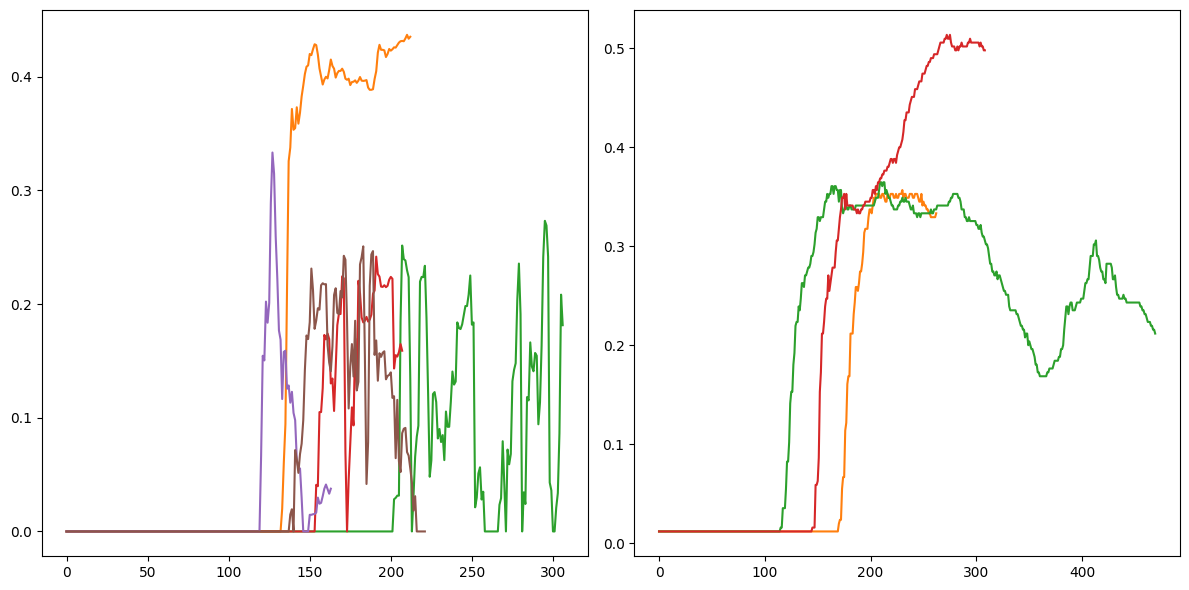

/home/hyperdog/octo/logs/tomato_forceless_4_28_233520


In [4]:
log_path = '/home/hyperdog/octo/logs/'
forcefullpath = get_latest_directory(log_path, 'forcefull') 
forcelesspath = get_latest_directory(log_path, 'forceless') 
forcefiles = [f for f in listdir(forcefullpath) if isfile(join(forcefullpath, f))]
forcelessfiles = [f for f in listdir(forcelesspath) if isfile(join(forcelesspath, f))]
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for file in forcefiles:
    data = np.load(forcefullpath / file, allow_pickle=True)
    axs[0].plot(data)
for file in forcelessfiles:
    data = np.load(forcelesspath / file, allow_pickle=True)
    axs[1].plot(data)

plt.tight_layout()
plt.show()
print(forcelesspath)